# BeforeIT analysys

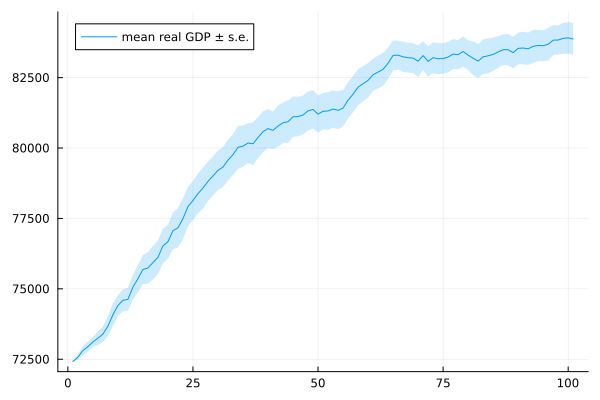

In [4]:
import BeforeIT as Bit
using Plots, Statistics, Random

parameters = Bit.AUSTRIA2010Q1.parameters
initial_conditions = Bit.AUSTRIA2010Q1.initial_conditions

T, n_sims = 100, 20
base = Bit.Model(parameters, initial_conditions)
models = Bit.ensemblerun!([deepcopy(base) for _ in 1:n_sims], T)
dv = Bit.DataVector(models)          # fields become T × n_sims matrices

g = dv.real_gdp
m, s = mean(g, dims=2), std(g, dims=2) ./ sqrt(n_sims)
plot(m, ribbon=s, fillalpha=0.2, label="mean real GDP ± s.e.")

In [5]:
using DataFrames
using CSV

function to_dataframe(dv)
    n_periods, n_sims = size(dv.collection_time)

    df = DataFrame(
        simulation = repeat(1:n_sims, inner = n_periods),
        time = vec(dv.collection_time),
    )

    for name in fieldnames(Bit.Data)
        name == :collection_time && continue

        values = getproperty(dv, name)

        # Inclui apenas séries escalares; dados setoriais são aninhados.
        eltype(values) <: Number || continue

        df[!, name] = vec(values)
    end

    return df
end

to_dataframe (generic function with 1 method)

In [7]:
df = to_dataframe(dv)

Row,simulation,time,nominal_gdp,real_gdp,nominal_gva,real_gva,nominal_household_consumption,real_household_consumption,nominal_government_consumption,real_government_consumption,nominal_capitalformation,real_capitalformation,nominal_fixed_capitalformation,real_fixed_capitalformation,nominal_fixed_capitalformation_dwellings,real_fixed_capitalformation_dwellings,nominal_exports,real_exports,nominal_imports,real_imports,operating_surplus,compensation_employees,wages,taxes_production,gdp_deflator_growth_ea,real_gdp_ea,euribor,gambling_volume
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1,72422.0,72422.0,64900.9,64900.9,40512.9,40512.9,14866.9,14866.9,15944.2,15944.2,15944.2,15944.2,3173.23,3173.23,34195.6,34195.6,33097.6,33097.6,29576.1,34346.7,28335.3,978.062,0.00193832,2.35485e6,0.00164593,0.0
2,1,2,73083.7,72560.7,65497.1,65028.4,40883.2,40590.7,14624.3,14519.7,16655.4,16536.2,16090.5,15975.4,3202.24,3179.32,34561.2,34313.8,33640.4,33399.7,29847.8,34662.2,28595.6,987.046,0.00595907,2.37637e6,0.00255995,0.0
3,1,3,73790.2,72625.0,66126.3,65082.1,41366.0,40712.8,14460.9,14232.6,16825.6,16559.9,16260.4,16003.6,3240.05,3188.88,35194.7,34638.9,34056.9,33519.1,30191.5,34938.0,28823.1,996.773,0.00673265,2.3774e6,0.00256745,0.0
4,1,4,74169.1,72748.9,66459.5,65187.0,41647.5,40850.1,14707.4,14425.8,16496.8,16180.9,16359.5,16046.3,3262.1,3199.64,35836.6,35150.4,34519.1,33858.2,30401.4,35057.8,28922.0,1000.33,0.00176414,2.37247e6,0.00221404,0.0
5,1,5,74631.5,72720.7,66867.9,65155.9,41938.4,40864.6,14923.1,14541.0,16798.5,16368.4,16456.0,16034.6,3284.88,3200.78,35901.9,34982.7,34930.3,34036.0,30563.5,35296.6,29119.0,1007.82,0.00450509,2.36121e6,0.00168657,0.0
6,1,6,74434.7,72289.3,66676.6,64754.8,41905.1,40697.2,14980.7,14549.0,16305.6,15835.7,16405.4,15932.5,3282.27,3187.67,35790.9,34759.3,34547.6,33551.8,30447.1,35222.5,29057.8,1007.01,0.00566266,2.37172e6,0.00212931,0.0
7,1,7,75779.3,72748.1,67896.8,65180.9,42546.5,40844.6,15437.7,14820.2,16486.4,15826.9,16698.2,16030.2,3333.0,3199.67,35214.6,33806.0,33905.9,32549.6,30997.3,35873.0,29594.5,1026.51,0.00486246,2.37437e6,0.00219343,0.0
8,1,8,75331.6,72030.1,67479.5,64522.0,42347.0,40491.1,15637.5,14952.1,16021.8,15319.6,16606.7,15878.9,3316.89,3171.52,36353.7,34760.4,35028.4,33493.2,30784.5,35680.7,29435.9,1014.27,0.00733142,2.38551e6,0.00266055,0.0
9,1,9,75055.8,71705.6,67256.4,64254.4,41963.3,40090.3,15663.2,14964.0,16300.9,15573.3,16518.4,15781.1,3295.8,3148.69,36487.6,34859.0,35359.2,33780.9,30619.1,35619.4,29385.3,1017.9,0.00522226,2.40478e6,0.00337791,0.0


In [9]:
CSV.write("study-output.csv", df)

"study-output.csv"

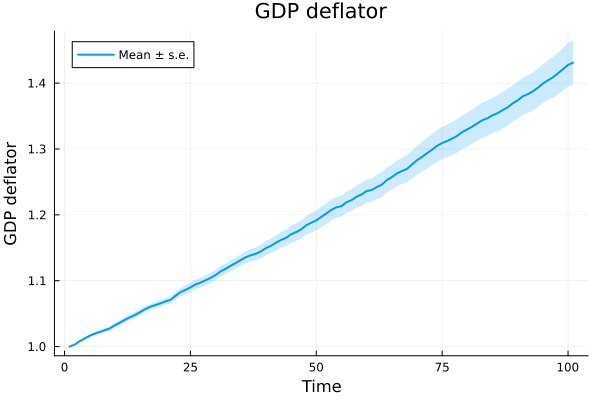

In [20]:
df.gdp_deflator = df.nominal_gdp ./ df.real_gdp

summary = combine(
    groupby(df, :time),
    :gdp_deflator => mean => :average,
    :gdp_deflator => (x -> std(x) / sqrt(length(x))) => :standard_error,
)

sort!(summary, :time)

plot(
    summary.time,
    summary.average;
    ribbon = summary.standard_error,
    label = "Mean ± s.e.",
    xlabel = "Time",
    ylabel = "GDP deflator",
    title = "GDP deflator",
    linewidth = 2,
    fillalpha = 0.2,
)

In [ ]:
sort!(df, [:simulation, :time])

transform!(
    groupby(df, :simulation),
    :real_gdp => (x -> [
        missing
        100 .* (x[2:end] ./ x[1:(end - 1)] .- 1)
    ]) => :real_gdp_growth,
)

growth_summary = combine(
    groupby(dropmissing(df, :real_gdp_growth), :time),
    :real_gdp_growth => mean => :average,
    :real_gdp_growth =>
        (x -> std(x) / sqrt(length(x))) => :standard_error,
)

plot(
    growth_summary.time,
    growth_summary.average;
    ribbon = growth_summary.standard_error,
    label = "Mean ± s.e.",
    xlabel = "Time",
    ylabel = "Real GDP growth (%)",
    title = "Real GDP growth",
)

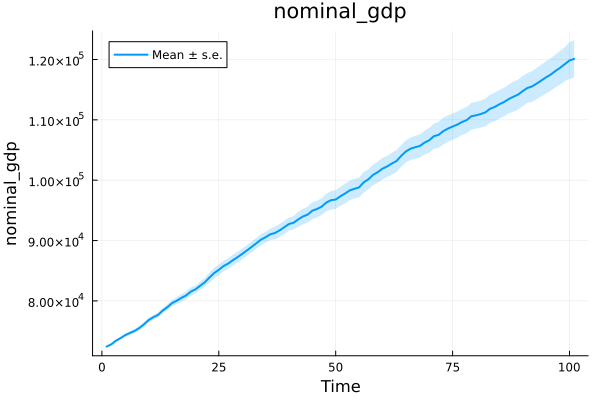

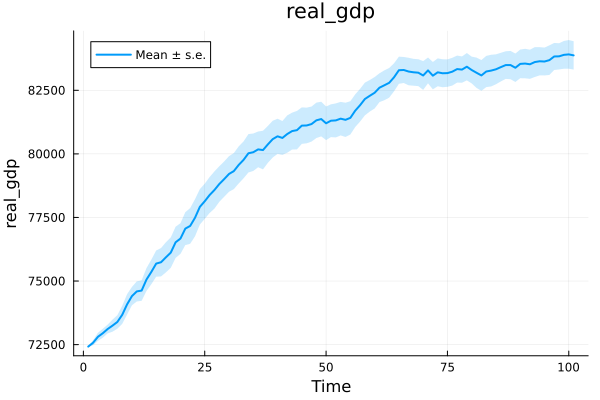

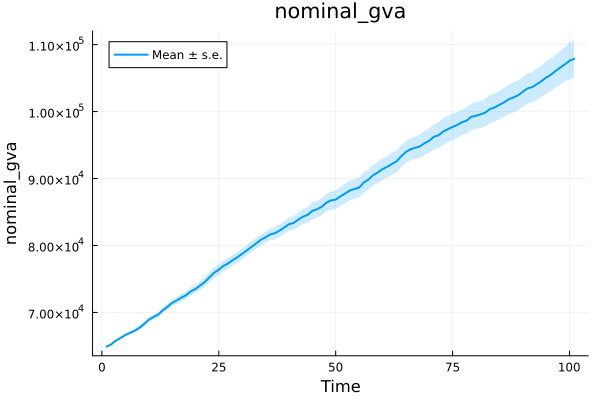

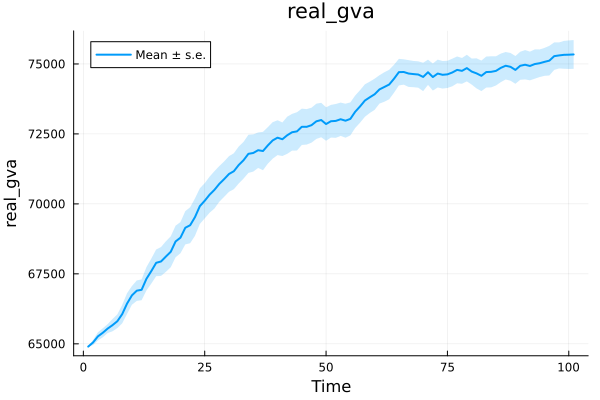

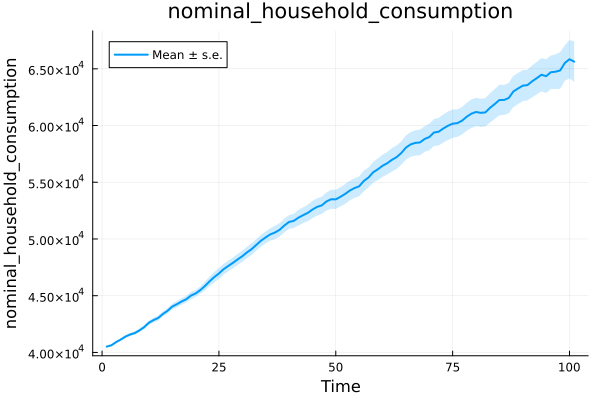

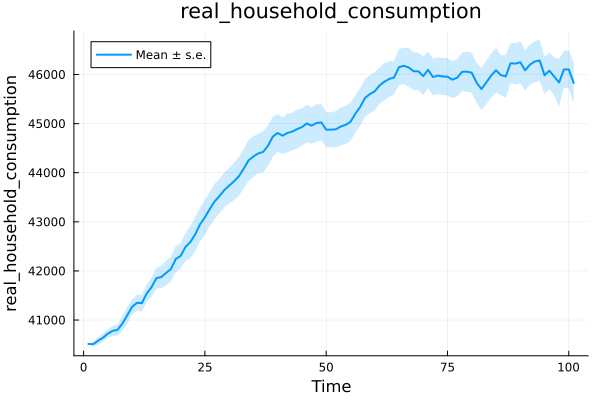

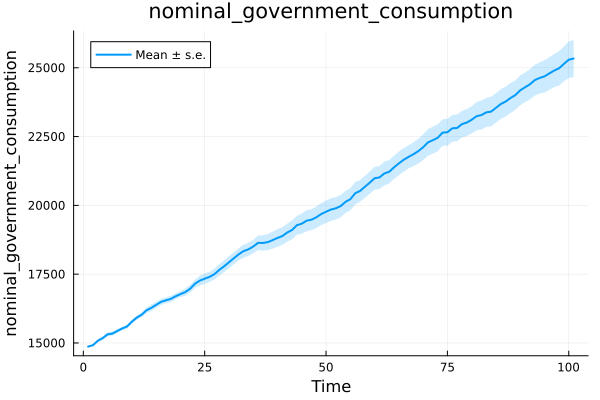

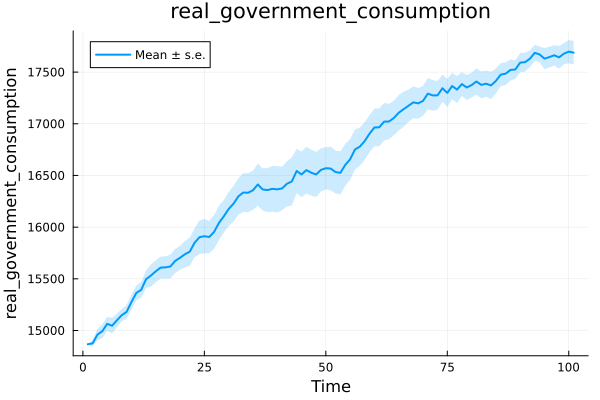

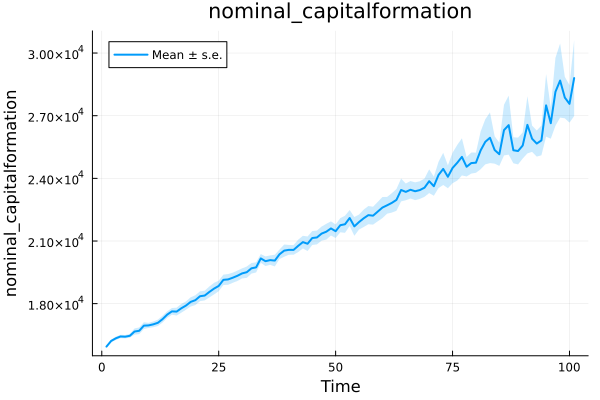

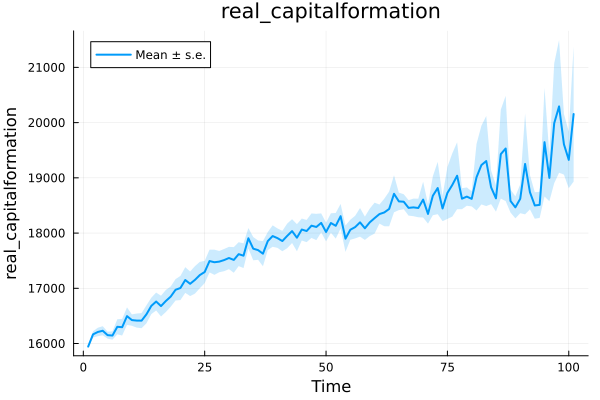

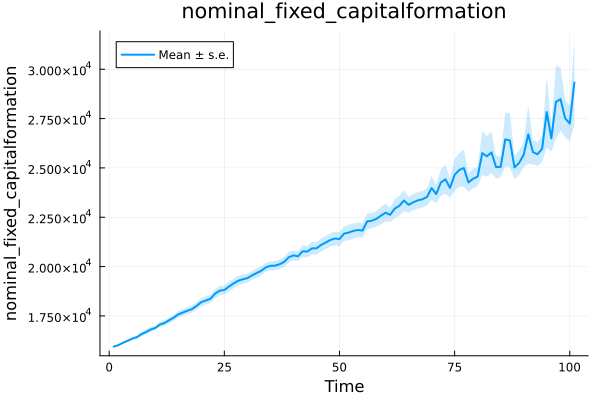

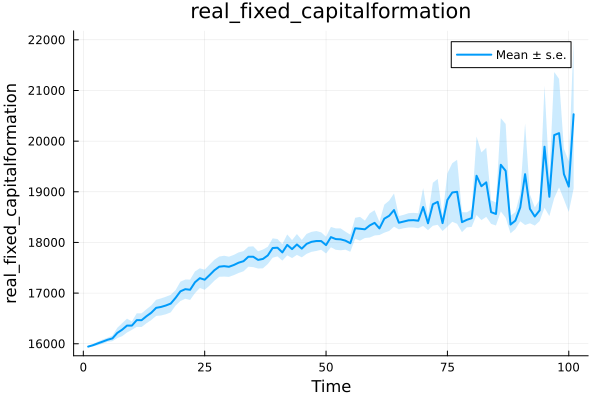

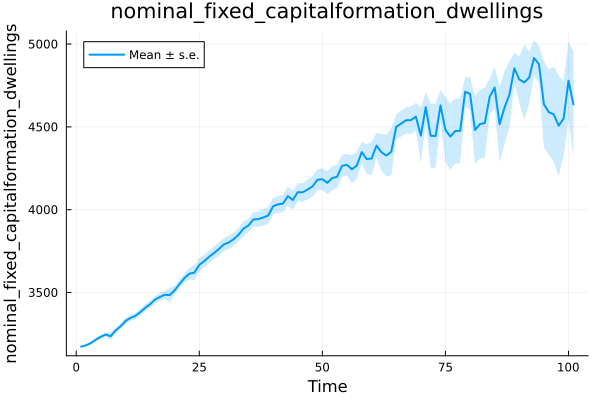

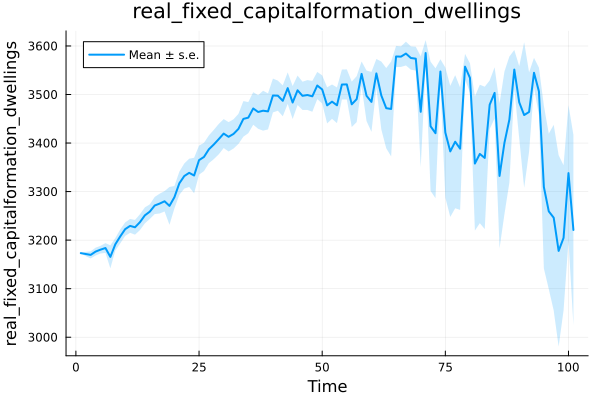

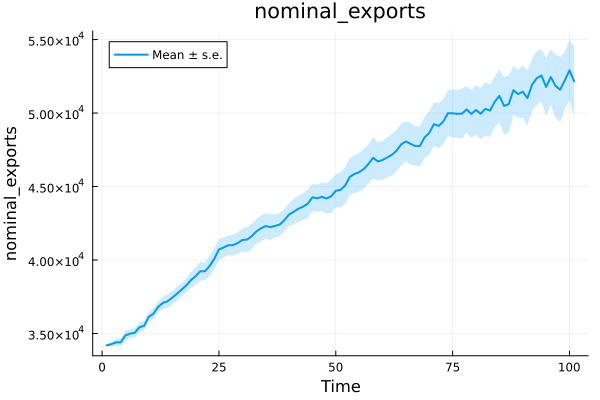

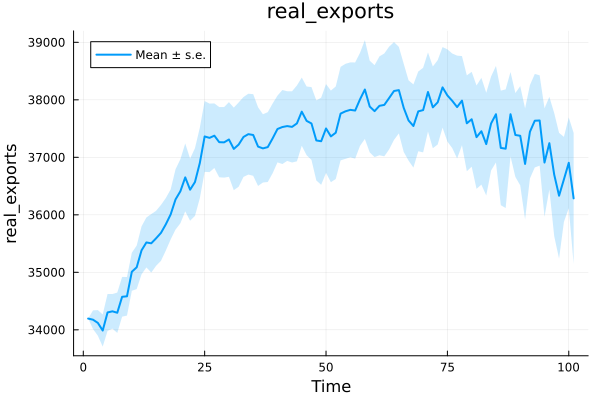

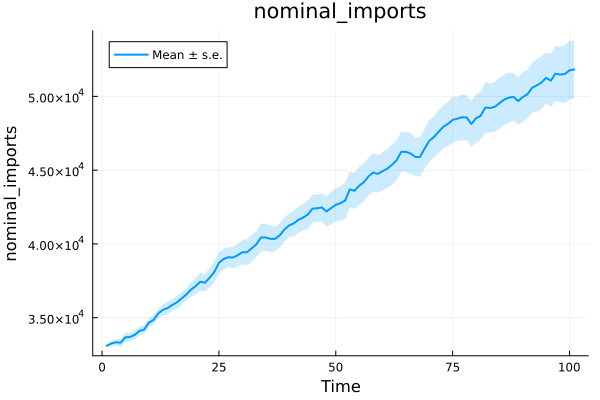

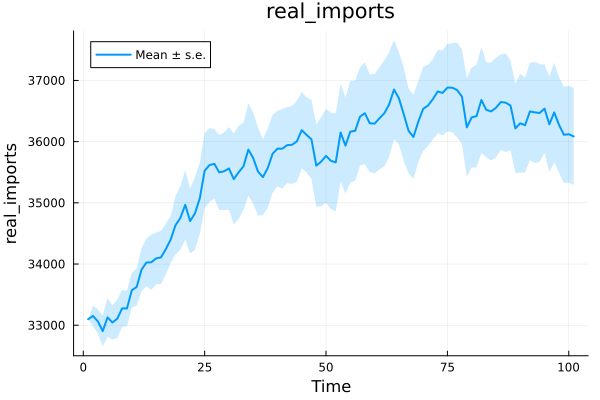

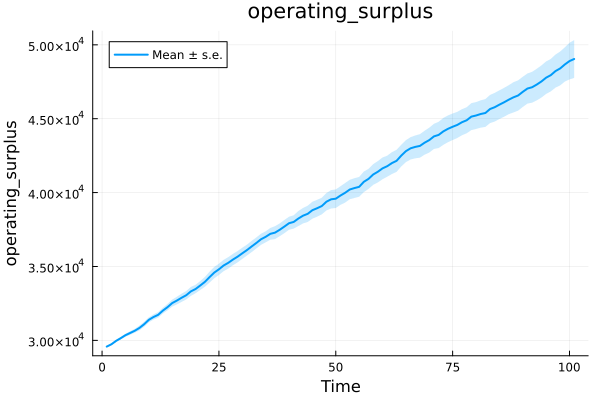

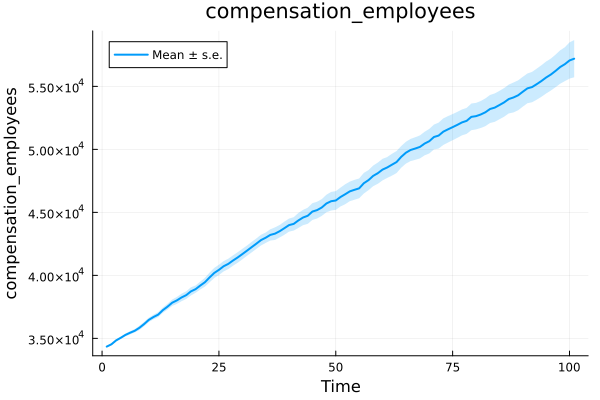

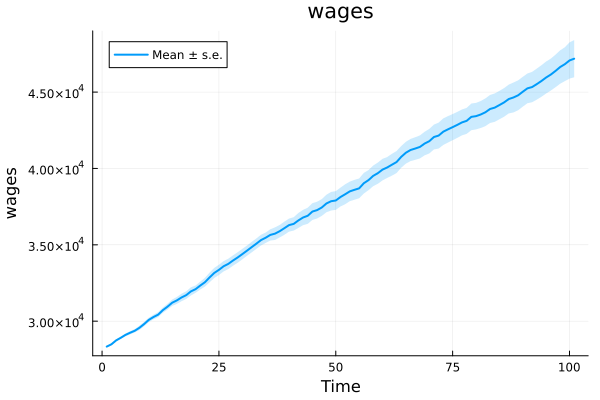

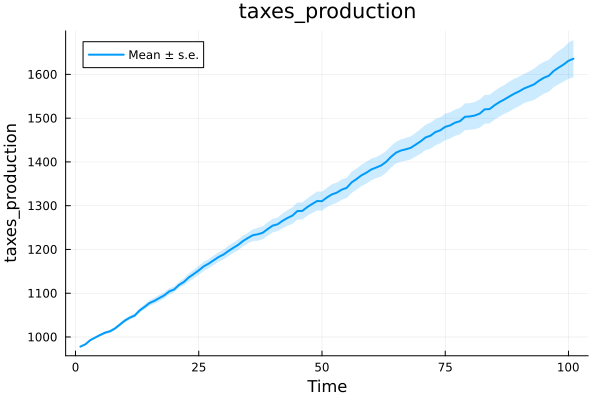

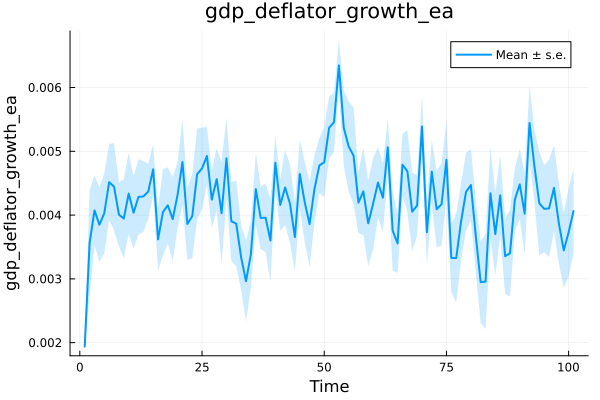

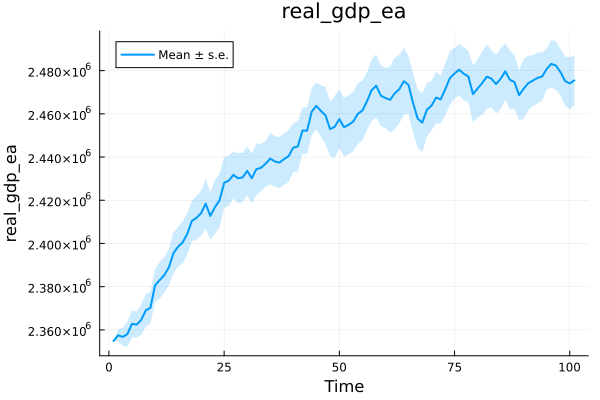

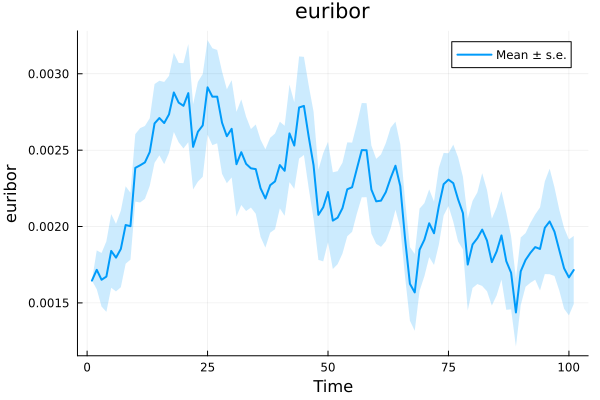

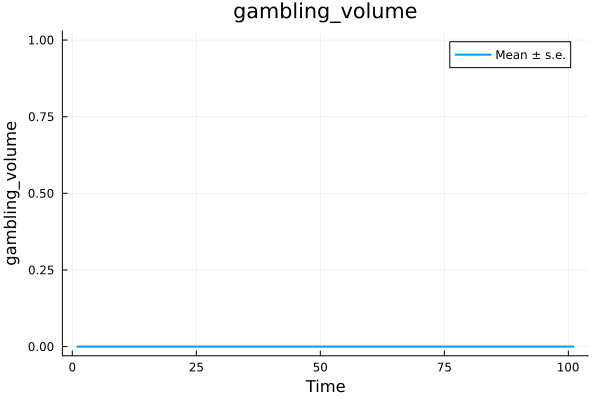

In [8]:
 n_sims = length(unique(df.simulation))

  for name in names(df)
      name in ("time", "simulation") && continue
      eltype(df[!, name]) <: Number || continue

      summary = combine(
          groupby(df, :time),
          name => mean => :average,
          name => std => :standard_deviation,
      )

      sort!(summary, :time)

      standard_error =
          summary.standard_deviation ./ sqrt(n_sims)

      p = plot(
          summary.time,
          summary.average;
          ribbon = standard_error,
          fillalpha = 0.2,
          linewidth = 2,
          label = "Mean ± s.e.",
          title = name,
          xlabel = "Time",
          ylabel = name,
      )

      display(p)

      # Optional:
      # savefig(p, "$(name).png")
  end